## imports

In [1]:
import numpy as np
from itertools import combinations
from collections import Counter
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import colorsys
from concurrent.futures import ThreadPoolExecutor, as_completed
from os import cpu_count
from tqdm import tqdm

## computation

In [2]:
def ray_region_representatives(points: np.ndarray) -> list[np.ndarray]:
    """
    Given m points in general position (shape (m, 2)), consider the arrangement
    formed by taking the line through every pair of points and removing the
    segment between them, leaving 2 rays per pair. Returns a list of
    representative points, one per region of this arrangement.
    """
    pairs = list(combinations(range(len(points)), 2))

    # Find all vertices (line-line intersections) ---
    vertices = list(points)
    for (a, b), (c, d) in combinations(pairs, 2):
        pt = _line_line_intersection(points[a], points[b], points[c], points[d])
        if pt is not None:
            vertices.append(pt)
    vertices = np.array(vertices)

    # Candidate x-values ---
    xs = np.sort(np.unique(np.round(vertices[:, 0], 10)))
    margin = 1.0
    x_vals = np.concatenate([
        [xs[0] - margin],
        (xs[:-1] + xs[1:]) / 2 if len(xs) > 1 else [],
        [xs[-1] + margin],
    ])

    # Sample candidate points in each vertical slice ---
    candidates = []
    for x in x_vals:
        y_crossings = []
        for a, b in pairs:
            y = _line_x_crossing(points[a], points[b], x)
            if y is not None:
                y_crossings.append(y)

        y_crossings = sorted(set(np.round(y_crossings, 10)))

        if y_crossings:
            sample_ys = (
                [y_crossings[0] - margin]
                + [(y_crossings[k] + y_crossings[k+1]) / 2
                   for k in range(len(y_crossings) - 1)]
                + [y_crossings[-1] + margin]
            )
        else:
            sample_ys = [0.0]

        for y in sample_ys:
            candidates.append(np.array([x, y]))

    # Assign each candidate a line-arrangement signature ---
    # Two points in the same line-arrangement face have identical signatures.
    line_sig_to_pts = {}
    for pt in candidates:
        sig = _line_signature(pt, points, pairs)
        if sig not in line_sig_to_pts:
            line_sig_to_pts[sig] = pt

    # Merge faces that are separated only by a segment, not a ray ---
    # Two line-arrangement faces should be merged if they are adjacent across
    # a segment p_i p_j. We detect this by finding, for each pair (i,j), a
    # point just above the midpoint of the segment and just below it. If their
    # line signatures differ only in the sign for pair (i,j), they are in faces
    # that should be merged.
    parent = {sig: sig for sig in line_sig_to_pts}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        parent[find(x)] = find(y)

    for idx, (i, j) in enumerate(pairs):
        pi, pj = points[i], points[j]
        d = pj - pi
        perp = np.array([-d[1], d[0]])
        perp = perp / np.linalg.norm(perp) * 1e-6

        # Find all points where other lines cross this segment,
        # expressed as t-values in [0, 1] along pi -> pj
        t_vals = [0.0, 1.0]
        for k, l in pairs:
            if i in (k, l) or j in (k, l):
                continue  # shares an endpoint, won't cross interior
            pt = _line_line_intersection(pi, pj, points[k], points[l])
            if pt is None:
                continue
            t = np.dot(pt - pi, d) / np.dot(d, d)
            if 1e-9 < t < 1 - 1e-9:
                t_vals.append(t)

        t_vals = sorted(set(np.round(t_vals, 10)))

        # Sample across each sub-segment
        for ta, tb in zip(t_vals[:-1], t_vals[1:]):
            mid = pi + (ta + tb) / 2 * d
            sig_above = _line_signature(mid + perp, points, pairs)
            sig_below = _line_signature(mid - perp, points, pairs)
            if sig_above in parent and sig_below in parent:
                union(sig_above, sig_below)

    # One representative per merged component ---
    components = {}
    for sig, pt in line_sig_to_pts.items():
        root = find(sig)
        if root not in components:
            components[root] = pt

    return list(components.values())

def _line_signature(pt, points, pairs):
    sig = []
    for i, j in pairs:
        d = points[j] - points[i]
        cross = _cross2(pt - points[i], d)
        sig.append(1 if cross > 0 else -1)
    return tuple(sig)

def _cross2(a, b):
    return a[0] * b[1] - a[1] * b[0]

def _line_line_intersection(p1, p2, p3, p4):
    d1, d2 = p2 - p1, p4 - p3
    denom = _cross2(d1, d2)
    if abs(denom) < 1e-12:
        return None
    t = _cross2(p3 - p1, d2) / denom
    return p1 + t * d1

def _line_x_crossing(p1, p2, x):
    dx = p2[0] - p1[0]
    if abs(dx) < 1e-12:
        return None
    t = (x - p1[0]) / dx
    return p1[1] + t * (p2[1] - p1[1])

In [3]:
def angular_orders_batch(pts, probes, verbose):
    """
    Given m input points and a set of probes, compute the angular ordering of
    the input points from each probe.
    """
    probes = np.array(probes)  # (Q, 2)
    diffs  = pts[None, :, :] - probes[:, None, :]  # (Q, m, 2)
    angles = np.arctan2(diffs[:, :, 1], diffs[:, :, 0])  # (Q, m)
    order  = np.argsort(angles, axis=1)  # (Q, m)
    
    orderings = set()
    regions_per_ord = Counter()
    for row in order:
        lst = list(row)
        p1_pos = lst.index(0)
        t = tuple(lst[p1_pos:] + lst[:p1_pos])
        orderings.add(t)
        regions_per_ord[t] += 1
    
    if verbose:
        mult_found = False
        print("\nOrderings with more than one corresponding region:")
        for t in orderings:
            if regions_per_ord[t] > 1:
                mult_found = True
                print(f"\t{t}")
        if not mult_found:
            print("\tnone")
        
        num_central_ord_regions = regions_per_ord[tuple(range(len(pts)))]
        print(f"\nThere {'are' if num_central_ord_regions > 1 else 'is'}"
              f" {num_central_ord_regions} region{'s' if num_central_ord_regions > 1 else ''}"
              f" corresponding to the central ordering.")
    
        mult_inverted = Counter()  # number of orderings that have each number of regions
        for k, v in regions_per_ord.items():
            mult_inverted[v] += 1
        for k, v in sorted(mult_inverted.items()):
            print(f"There {'are' if v > 1 else 'is'} {v} ordering{'s' if v > 1 else ''}"
                  f" with {k} corresponding region{'s' if k > 1 else ''}.")
    
    return orderings

In [4]:
def run_trial(m, mode, verbose, eps, seed):
    match mode:
        case "circular":
            alpha = np.sqrt(2)  # must be irrational

            m_range = np.arange(m)
            angles = (2 * np.pi * m_range / m) + (m_range**2 / (m**3))

            pts = np.column_stack((np.cos(angles), np.sin(angles)))
        case "circular_with_center":
            alpha = np.sqrt(2)  # must be irrational

            m_minus_one_range = np.arange(m-1)
            angles = (2 * np.pi * m_minus_one_range / (m-1)) + (m_minus_one_range**2 / ((m-1)**3))

            pts = np.column_stack((np.cos(angles), np.sin(angles)))
            
            center_pt = _sample_convex_polygon(pts, seed)
            pts = np.vstack((center_pt, pts))
        case "convex":
            pts = _random_convex_polygon(m, seed)
        case "random":
            rng  = np.random.default_rng(seed)
            pts = rng.uniform(-1, 1, (m, 2))
        case _:
            raise ValueError

    L = ray_region_representatives(pts)

    orderings = angular_orders_batch(pts, L, verbose=verbose)
    return pts, orderings, len(L)

import numpy as np


def _sample_convex_polygon(vertices, seed):
    rng  = np.random.default_rng(seed)
    
    v0 = vertices[0]

    triangles = np.stack([
        np.repeat(v0[None, :], len(vertices) - 2, axis=0),
        vertices[1:-1],
        vertices[2:]
    ], axis=1)

    a = triangles[:, 1] - triangles[:, 0]
    b = triangles[:, 2] - triangles[:, 0]

    areas = 0.5 * np.abs(a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0])

    A, B, C = triangles[rng.choice(len(triangles), p=areas / areas.sum())]

    u = rng.random()
    v = rng.random()

    if u + v > 1:
        u = 1 - u
        v = 1 - v

    return A + u * (B - A) + v * (C - A)


def _random_convex_polygon(m, seed):
    """
    Generate m points forming a random convex polygon using Valtr's algorithm.
    All points lie on the convex hull and are in counter-clockwise order.
    Output is scaled to fit within [-1, 1] x [-1, 1].
    """
    if m < 3:
        raise ValueError("Need at least 3 points for a convex polygon.")

    rng  = np.random.default_rng(seed)
    
    xs = np.sort(rng.uniform(0, 1, m))
    ys = np.sort(rng.uniform(0, 1, m))

    def build_vectors(vals):
        lo, hi = vals[0], vals[-1]
        pos, neg = [], []
        last_pos = last_neg = lo
        for v in vals[1:-1]:
            if rng.random() < 0.5:
                pos.append(v - last_pos); last_pos = v
            else:
                neg.append(v - last_neg); last_neg = v
        pos.append(hi - last_pos)
        neg.append(hi - last_neg)
        return np.array(pos + [-d for d in neg])

    dx = build_vectors(xs)
    dy = build_vectors(ys)

    rng.shuffle(dy)

    order = np.argsort(np.arctan2(dy, dx))
    dx, dy = dx[order], dy[order]

    pts = np.column_stack([np.cumsum(dx), np.cumsum(dy)])
    
    lo = pts.min(axis=0)
    hi = pts.max(axis=0)
    pts = (pts - lo) / (hi - lo) * 2 - 1

    return pts

In [5]:
def run_best_of_n(m, n_trials, mode, verbose, eps=1e-7, base_seed=0):
    workers = max(1, cpu_count() - 1)
    print(f"Running until {n_trials} trials with {workers} workers...")

    best_pts, best_orderings, best_num_regions = None, None, None
    valid = 0

    with ThreadPoolExecutor(max_workers=workers) as pool:
        with tqdm(total=n_trials, desc=f"m={m}", unit=" trial") as pbar:
            futures = {}
            
            def submit_batch(n):
                for _ in range(n):
                    seed = base_seed + valid
                    f = pool.submit(run_trial, m, mode, verbose, eps, seed)
                    futures[f] = seed

            submit_batch(workers * 4)

            while valid < n_trials:
                done = as_completed(futures)
                f = next(done)
                futures.pop(f)
                submit_batch(1)  # keep pool topped up
                result = f.result()
                valid += 1
                pbar.update(1)
                pts, orderings, num_regions = result
                if best_orderings is None or len(orderings) > len(best_orderings):
                    best_pts = pts
                    best_orderings = orderings
                    best_num_regions = num_regions
                    pbar.set_postfix(best=len(best_orderings))

    print(f"Best: {len(best_orderings)} ordering{'s' if len(best_orderings) > 1 else ''}"
          f" over {valid} trials")
    return best_pts, best_orderings, best_num_regions

## visualization

In [6]:
def visualize(pts, orderings, num_regions, m, eps=1e-7, grid_res=600):
    pairs = list(combinations(range(m), 2))
    p1_idx = 0
    BOUNDS = (-5, 5)

    lin = np.linspace(BOUNDS[0], BOUNDS[1], grid_res)
    gx, gy = np.meshgrid(lin, lin)
    grid = np.stack([gx.ravel(), gy.ravel()], axis=1)  # (grid_res^2, 2)

    diffs  = pts[None, :, :] - grid[:, None, :]  # (Q, m, 2)
    angles = np.arctan2(diffs[:, :, 1], diffs[:, :, 0])  # (Q, m)
    order  = np.argsort(angles, axis=1)  # (Q, m)

    p1_pos = np.argmax(order == p1_idx, axis=1)  # (Q,)
    q = len(grid)
    idx = (np.arange(m)[None, :] + p1_pos[:, None]) % m
    rotated = order[np.arange(q)[:, None], idx]  # (Q, m)

    color_map = _make_color_map(orderings)

    img = np.zeros((q, 4))
    unique_rows, inverse = np.unique(rotated, axis=0, return_inverse=True)
    for k, row in enumerate(unique_rows):
        img[inverse == k] = color_map[tuple(row)]

    img = img.reshape(grid_res, grid_res, 4)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, extent=[BOUNDS[0], BOUNDS[1], BOUNDS[0], BOUNDS[1]],
              origin='lower', zorder=0)
    ax.set_xlim(*BOUNDS); ax.set_ylim(*BOUNDS)
    ax.set_aspect('equal')
    ax.set_title(
        f"m={m}"
        f" | {len(orderings)} ordering{'s' if len(orderings) > 1 else ''}"
        f" | {num_regions} region{'s' if num_regions > 1 else ''}", 
        fontsize=13
    )

    def clip_ray(origin, direction):
        ts = []
        for dim in range(2):
            if abs(direction[dim]) > 1e-12:
                for bound in BOUNDS:
                    t = (bound - origin[dim]) / direction[dim]
                    if t > 1e-9:
                        ts.append(t)
        if not ts:
            return None
        t_end = min(ts)
        return origin, origin + t_end * direction

    for i_, j_ in pairs:
        p, q_ = pts[i_], pts[j_]
        d = (q_ - p) / np.linalg.norm(q_ - p)
        for origin, direction in [(p, -d), (q_, d)]:
            seg = clip_ray(origin, direction)
            if seg is not None:
                ax.plot([seg[0][0], seg[1][0]], [seg[0][1], seg[1][1]],
                        color='black', lw=0.8, zorder=1)

    for i_, p in enumerate(pts):
        label = f"P{i_}"
        ax.plot(p[0], p[1], 'ko', markersize=8, zorder=2)
        ax.annotate(label, p, textcoords="offset points", xytext=(6, 4),
                    fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

def _make_color_map(orderings):
    sorted_orderings = sorted(orderings)
    n = len(sorted_orderings)
    colors = {}
    for i, o in enumerate(sorted_orderings):
        hue = i / n
        r, g, b = colorsys.hsv_to_rgb(hue, 1.0, 0.8)
        colors[o] = (r, g, b, 1.0)
    return colors

## experiments



=== m = 3 ===
circular:

Orderings with more than one corresponding region:
	(0, 2, 1)

There is 1 region corresponding to the central ordering.
There is 1 ordering with 1 corresponding region.
There is 1 ordering with 3 corresponding regions.

2 orderings
4 regions


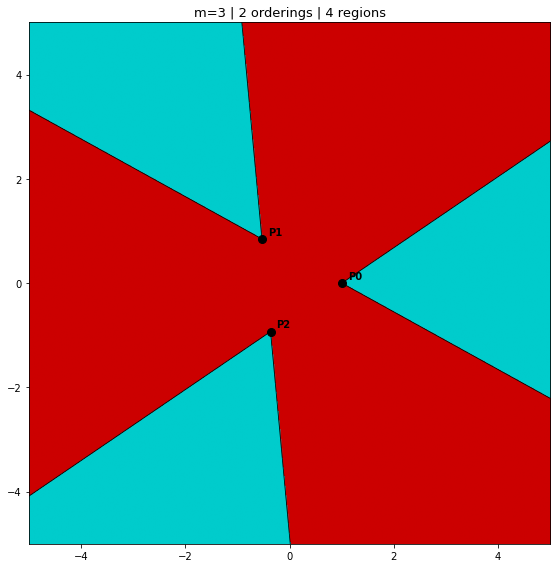



=== m = 4 ===
circular:

Orderings with more than one corresponding region:
	(0, 2, 1, 3)
	(0, 3, 1, 2)
	(0, 2, 3, 1)
	(0, 1, 3, 2)
	(0, 3, 2, 1)

There is 1 region corresponding to the central ordering.
There is 1 ordering with 1 corresponding region.
There are 5 orderings with 2 corresponding regions.

6 orderings
11 regions


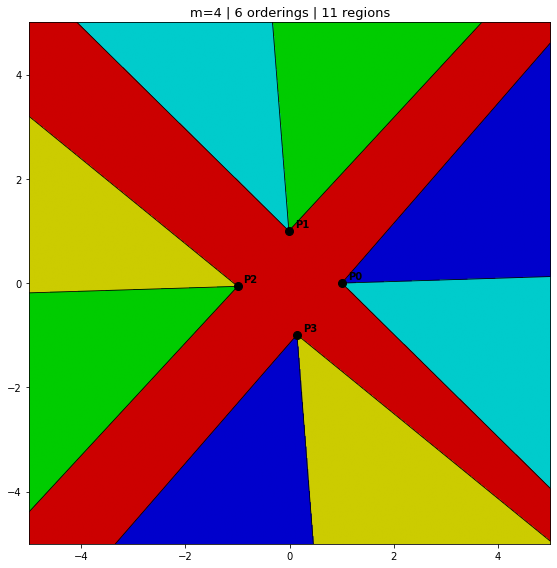



=== m = 5 ===
circular:

Orderings with more than one corresponding region:
	(0, 2, 1, 3, 4)
	(0, 4, 2, 3, 1)
	(0, 2, 3, 4, 1)
	(0, 1, 3, 2, 4)
	(0, 1, 2, 4, 3)
	(0, 4, 1, 2, 3)

There is 1 region corresponding to the central ordering.
There are 14 orderings with 1 corresponding region.
There are 6 orderings with 2 corresponding regions.

20 orderings
26 regions


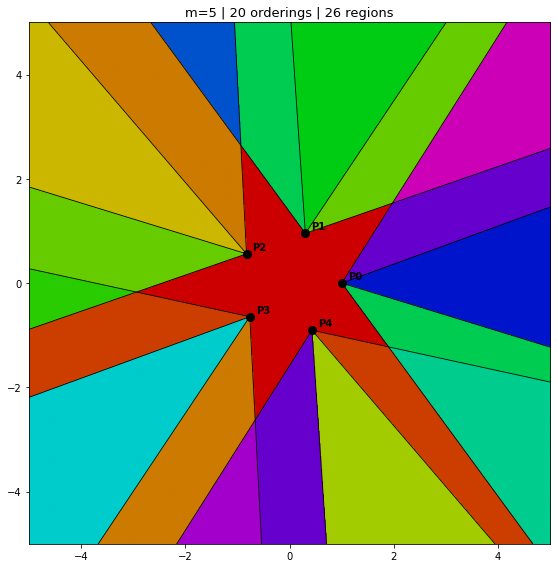



=== m = 6 ===
circular:

Orderings with more than one corresponding region:
	(0, 1, 2, 4, 3, 5)
	(0, 2, 1, 3, 4, 5)
	(0, 2, 3, 4, 5, 1)
	(0, 1, 3, 2, 4, 5)
	(0, 1, 2, 3, 5, 4)
	(0, 5, 2, 3, 4, 1)
	(0, 5, 1, 2, 3, 4)

There is 1 region corresponding to the central ordering.
There are 41 orderings with 1 corresponding region.
There are 7 orderings with 2 corresponding regions.

48 orderings
55 regions


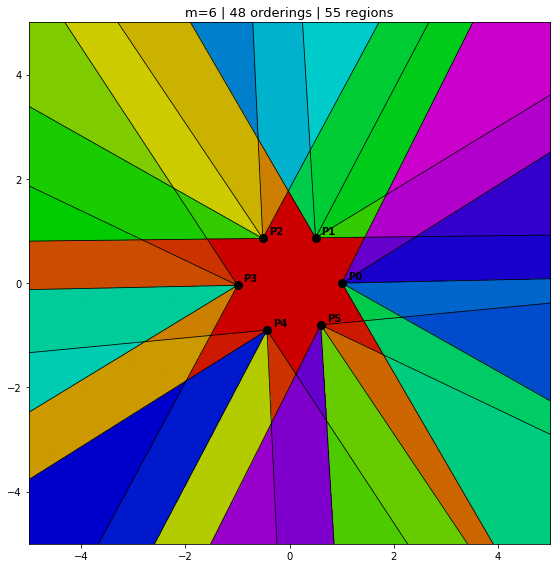



=== m = 7 ===
circular:

Orderings with more than one corresponding region:
	(0, 1, 2, 3, 5, 4, 6)
	(0, 1, 2, 3, 4, 6, 5)
	(0, 2, 3, 4, 5, 6, 1)
	(0, 1, 3, 2, 4, 5, 6)
	(0, 6, 1, 2, 3, 4, 5)
	(0, 1, 2, 4, 3, 5, 6)
	(0, 2, 1, 3, 4, 5, 6)

There is 1 region corresponding to the central ordering.
There are 92 orderings with 1 corresponding region.
There are 7 orderings with 2 corresponding regions.

99 orderings
106 regions


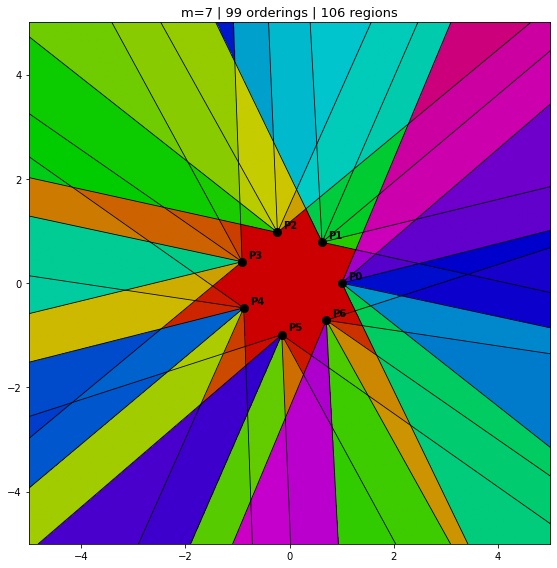



=== m = 8 ===
circular:

Orderings with more than one corresponding region:
	(0, 2, 1, 3, 4, 5, 6, 7)
	(0, 1, 2, 3, 4, 5, 7, 6)
	(0, 1, 2, 3, 5, 4, 6, 7)
	(0, 2, 3, 4, 5, 6, 7, 1)
	(0, 1, 2, 4, 3, 5, 6, 7)
	(0, 1, 2, 3, 4, 6, 5, 7)
	(0, 7, 1, 2, 3, 4, 5, 6)
	(0, 1, 3, 2, 4, 5, 6, 7)

There is 1 region corresponding to the central ordering.
There are 173 orderings with 1 corresponding region.
There are 8 orderings with 2 corresponding regions.

181 orderings
189 regions


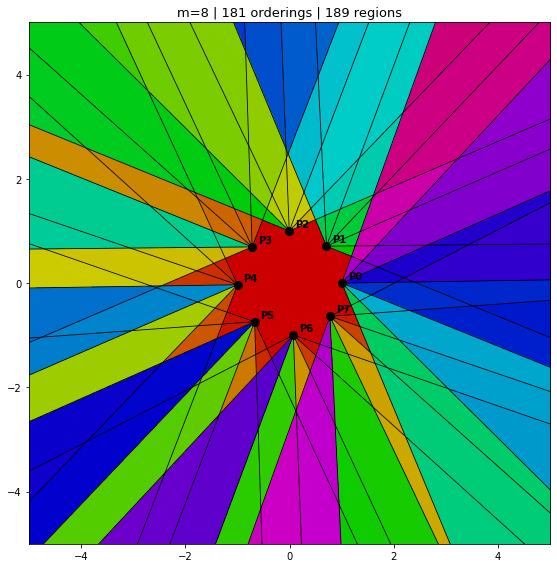



=== m = 9 ===
circular:

Orderings with more than one corresponding region:
	(0, 2, 3, 4, 5, 6, 7, 8, 1)
	(0, 1, 2, 3, 5, 4, 6, 7, 8)
	(0, 1, 2, 4, 3, 5, 6, 7, 8)
	(0, 1, 3, 2, 4, 5, 6, 7, 8)
	(0, 2, 1, 3, 4, 5, 6, 7, 8)
	(0, 8, 1, 2, 3, 4, 5, 6, 7)
	(0, 1, 2, 3, 4, 5, 6, 8, 7)
	(0, 1, 2, 3, 4, 6, 5, 7, 8)
	(0, 1, 2, 3, 4, 5, 7, 6, 8)

There is 1 region corresponding to the central ordering.
There are 298 orderings with 1 corresponding region.
There are 9 orderings with 2 corresponding regions.

307 orderings
316 regions


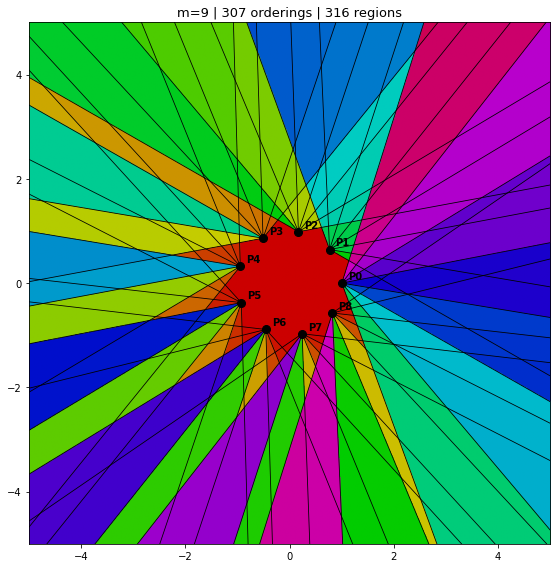



=== m = 10 ===
circular:

Orderings with more than one corresponding region:
	(0, 1, 2, 4, 3, 5, 6, 7, 8, 9)
	(0, 1, 2, 3, 4, 5, 7, 6, 8, 9)
	(0, 1, 2, 3, 4, 6, 5, 7, 8, 9)
	(0, 1, 3, 2, 4, 5, 6, 7, 8, 9)
	(0, 2, 1, 3, 4, 5, 6, 7, 8, 9)
	(0, 1, 2, 3, 4, 5, 6, 7, 9, 8)
	(0, 1, 2, 3, 4, 5, 6, 8, 7, 9)
	(0, 2, 3, 4, 5, 6, 7, 8, 9, 1)
	(0, 1, 2, 3, 5, 4, 6, 7, 8, 9)
	(0, 9, 1, 2, 3, 4, 5, 6, 7, 8)

There is 1 region corresponding to the central ordering.
There are 481 orderings with 1 corresponding region.
There are 10 orderings with 2 corresponding regions.

491 orderings
501 regions


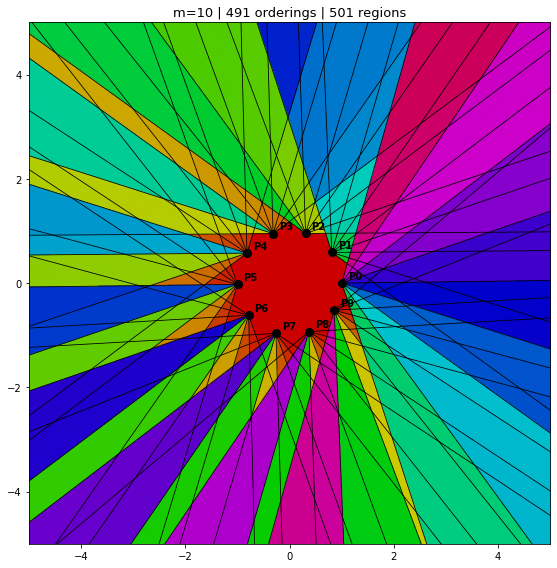

In [7]:
M_MIN = 3  # formula for number of regions does not hold for m < 2
M_MAX = 10  # numerical errors for m > 16
# M_RANGE = range(4, 15, 2)  # useful range for "circular_with_center" mode
M_RANGE = range(M_MIN, M_MAX + 1)
EPS = 1e-7
N_TRIALS = 1500
base_seed = np.random.randint(0, 10**6)
mode = "circular"
visuals_on = True

match mode:
    case "circular":
        for m in M_RANGE:
            print(f"\n\n=== m = {m} ===\n{mode}:")
            pts, orderings, num_regions = run_trial(m, mode, verbose=True, eps=EPS, seed=None)
            print(f"\n{len(orderings)} ordering{'s' if len(orderings) > 1 else ''}")
            print(f"{num_regions} region{'s' if num_regions > 1 else ''}")
            if visuals_on:
                visualize(pts, orderings, num_regions, m, eps=EPS)
    case "circular_with_center" | "random" | "convex":
        for m in M_RANGE:
            print(f"{mode}:")
            best_pts, best_orderings, best_num_regions = run_best_of_n(
                m, 
                N_TRIALS, 
                mode, 
                verbose=False, 
                eps=EPS, 
                base_seed=base_seed
            )
            if visuals_on:
                visualize(best_pts, best_orderings, best_num_regions, m, eps=EPS)
    case _:
        raise ValueError